In [575]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output # Only for iPython

#Helper function

In [576]:
def crossMat(a):
    """
    Returns the cross product matrix of vector 'a'.

    Parameters:
    a : np.ndarray
        A 3-element array representing a vector.

    Returns:
    A : np.ndarray
        The cross product matrix corresponding to vector 'a'.
    """
    A = np.array([[0, -a[2], a[1]],
                  [a[2], 0, -a[0]],
                  [-a[1], a[0], 0]])

    return A

#Gradient and Hessian of elastic energies

In [577]:
def gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the derivative of bending energy E_k^b with respect to
    x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dF : np.ndarray
        Derivative of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0.0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Gradient of bending energy
    dkappa = kappa1 - kappaBar
    dF = gradKappa * EI * dkappa / l_k

    return dF

In [578]:
def hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, curvature0, l_k, EI):
    """
    Returns the Hessian (second derivative) of bending energy E_k^b
    with respect to x_{k-1}, y_{k-1}, x_k, y_k, x_{k+1}, and y_{k+1}.

    Parameters:
    xkm1, ykm1 : float
        Coordinates of the previous node (x_{k-1}, y_{k-1}).
    xk, yk : float
        Coordinates of the current node (x_k, y_k).
    xkp1, ykp1 : float
        Coordinates of the next node (x_{k+1}, y_{k+1}).
    curvature0 : float
        Discrete natural curvature at node (xk, yk).
    l_k : float
        Voronoi length of node (xk, yk).
    EI : float
        Bending stiffness.

    Returns:
    dJ : np.ndarray
        Hessian of bending energy.
    """

    # Nodes in 3D
    node0 = np.array([xkm1, ykm1, 0])
    node1 = np.array([xk, yk, 0])
    node2 = np.array([xkp1, ykp1, 0])

    # Unit vectors along z-axis
    m2e = np.array([0, 0, 1])
    m2f = np.array([0, 0, 1])

    kappaBar = curvature0

    # Initialize gradient of curvature
    gradKappa = np.zeros(6)

    # Edge vectors
    ee = node1 - node0
    ef = node2 - node1

    # Norms of edge vectors
    norm_e = np.linalg.norm(ee)
    norm_f = np.linalg.norm(ef)

    # Unit tangents
    te = ee / norm_e
    tf = ef / norm_f

    # Curvature binormal
    kb = 2.0 * np.cross(te, tf) / (1.0 + np.dot(te, tf))

    chi = 1.0 + np.dot(te, tf)
    tilde_t = (te + tf) / chi
    tilde_d2 = (m2e + m2f) / chi

    # Curvature
    kappa1 = kb[2]

    # Gradient of kappa1 with respect to edge vectors
    Dkappa1De = 1.0 / norm_e * (-kappa1 * tilde_t + np.cross(tf, tilde_d2))
    Dkappa1Df = 1.0 / norm_f * (-kappa1 * tilde_t - np.cross(te, tilde_d2))

    # Populate the gradient of kappa
    gradKappa[0:2] = -Dkappa1De[0:2]
    gradKappa[2:4] = Dkappa1De[0:2] - Dkappa1Df[0:2]
    gradKappa[4:6] = Dkappa1Df[0:2]

    # Compute the Hessian (second derivative of kappa)
    DDkappa1 = np.zeros((6, 6))

    norm2_e = norm_e**2
    norm2_f = norm_f**2

    Id3 = np.eye(3)

    # Helper matrices for second derivatives
    tt_o_tt = np.outer(tilde_t, tilde_t)
    tmp = np.cross(tf, tilde_d2)
    tf_c_d2t_o_tt = np.outer(tmp, tilde_t)
    kb_o_d2e = np.outer(kb, m2e)

    D2kappa1De2 = (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt - tf_c_d2t_o_tt.T) / norm2_e - \
                  kappa1 / (chi * norm2_e) * (Id3 - np.outer(te, te)) + \
                  (kb_o_d2e + kb_o_d2e.T) / (4 * norm2_e)

    tmp = np.cross(te, tilde_d2)
    te_c_d2t_o_tt = np.outer(tmp, tilde_t)
    tt_o_te_c_d2t = te_c_d2t_o_tt.T
    kb_o_d2f = np.outer(kb, m2f)

    D2kappa1Df2 = (2 * kappa1 * tt_o_tt + te_c_d2t_o_tt + te_c_d2t_o_tt.T) / norm2_f - \
                  kappa1 / (chi * norm2_f) * (Id3 - np.outer(tf, tf)) + \
                  (kb_o_d2f + kb_o_d2f.T) / (4 * norm2_f)
    D2kappa1DeDf = -kappa1 / (chi * norm_e * norm_f) * (Id3 + np.outer(te, tf)) \
                  + 1.0 / (norm_e * norm_f) * (2 * kappa1 * tt_o_tt - tf_c_d2t_o_tt + \
                  tt_o_te_c_d2t - crossMat(tilde_d2))
    D2kappa1DfDe = D2kappa1DeDf.T

    # Populate the Hessian of kappa
    DDkappa1[0:2, 0:2] = D2kappa1De2[0:2, 0:2]
    DDkappa1[0:2, 2:4] = -D2kappa1De2[0:2, 0:2] + D2kappa1DeDf[0:2, 0:2]
    DDkappa1[0:2, 4:6] = -D2kappa1DeDf[0:2, 0:2]
    DDkappa1[2:4, 0:2] = -D2kappa1De2[0:2, 0:2] + D2kappa1DfDe[0:2, 0:2]
    DDkappa1[2:4, 2:4] = D2kappa1De2[0:2, 0:2] - D2kappa1DeDf[0:2, 0:2] - \
                         D2kappa1DfDe[0:2, 0:2] + D2kappa1Df2[0:2, 0:2]
    DDkappa1[2:4, 4:6] = D2kappa1DeDf[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 0:2] = -D2kappa1DfDe[0:2, 0:2]
    DDkappa1[4:6, 2:4] = D2kappa1DfDe[0:2, 0:2] - D2kappa1Df2[0:2, 0:2]
    DDkappa1[4:6, 4:6] = D2kappa1Df2[0:2, 0:2]

    # Hessian of bending energy
    dkappa = kappa1 - kappaBar
    dJ = 1.0 / l_k * EI * np.outer(gradKappa, gradKappa)
    dJ += 1.0 / l_k * dkappa * EI * DDkappa1

    return dJ

In [579]:
def gradEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    Calculate the gradient of the stretching energy with respect to the coordinates.

    Args:
    - xk (float): x coordinate of the current point
    - yk (float): y coordinate of the current point
    - xkp1 (float): x coordinate of the next point
    - ykp1 (float): y coordinate of the next point
    - l_k (float): reference length
    - EA (float): elastic modulus

    Returns:
    - F (np.array): Gradient array
    """
    F = np.zeros(4)
    F[0] = -(1.0 - np.sqrt((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0) / l_k) * ((xkp1 - xk)**2.0 + (ykp1 - yk)**2.0)**(-0.5) / l_k * (-2.0 * xkp1 + 2.0 * xk)
    F[1] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (-0.2e1 * ykp1 + 0.2e1 * yk)
    F[2] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * xkp1 - 0.2e1 * xk)
    F[3] = -(0.1e1 - np.sqrt((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k) * ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1) / l_k * (0.2e1 * ykp1 - 0.2e1 * yk)

    F = 0.5 * EA * l_k * F  # Scale by EA and l_k

    return F

In [580]:
def hessEs(xk, yk, xkp1, ykp1, l_k, EA):
    """
    This function returns the 4x4 Hessian of the stretching energy E_k^s with
    respect to x_k, y_k, x_{k+1}, and y_{k+1}.
    """
    J = np.zeros((4, 4))  # Initialize the Hessian matrix
    J11 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * xkp1 + 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J12 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (-2 * ykp1 + 2 * yk) / 0.2e1
    J13 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * xkp1 - 2 * xk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J14 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * xkp1 + 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * xkp1 + 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J22 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((-2 * ykp1 + 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J23 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * xkp1 - 2 * xk) / 0.2e1
    J24 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (-2 * ykp1 + 2 * yk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (-2 * ykp1 + 2 * yk) * (2 * ykp1 - 2 * yk) / 0.2e1 + 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J33 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * xkp1 - 2 * xk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * xkp1 - 2 * xk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k
    J34 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) * (2 * xkp1 - 2 * xk)) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * (2 * xkp1 - 2 * xk) * (2 * ykp1 - 2 * yk) / 0.2e1
    J44 = (1 / ((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) / l_k ** 2 * (2 * ykp1 - 2 * yk) ** 2) / 0.2e1 + (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.3e1 / 0.2e1)) / l_k * ((2 * ykp1 - 2 * yk) ** 2) / 0.2e1 - 0.2e1 * (0.1e1 - np.sqrt(((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2)) / l_k) * (((xkp1 - xk) ** 2 + (ykp1 - yk) ** 2) ** (-0.1e1 / 0.2e1)) / l_k

    J = np.array([[J11, J12, J13, J14],
                   [J12, J22, J23, J24],
                   [J13, J23, J33, J34],
                   [J14, J24, J34, J44]])

    J *= 0.5 * EA * l_k

    return J

# Functions to create elastic force vector and its Hessian

In [581]:
def getFs(q, EA, deltaL):
  # q - DOF vector of size N
  # EA - stretching stiffness
  # deltaL - undeformed reference length (assume to be a scalar for this simple example)
  # Output:
  # Fs - a vector (negative gradient of elastic stretching force)
  # Js - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fs = np.zeros(ndof) # stretching force
  Js = np.zeros((ndof, ndof))

  for k in range(0, N-1):
      # May need to modify if network of beams
      # k-th stretching spring (USE A LOOP for the general case
      xkm1 = q[2*k] # x coordinate of the first node
      ykm1 = q[2*k+1] # y coordinate of the first node
      xk = q[2*k+2] # x coordinate of the second node
      yk = q[2*k+3] # y coordinate of the second node
      ind = np.arange(2*k, 2*k+4) # 0, 1, 2, 3 for k = 0
      gradEnergy = gradEs(xkm1, ykm1, xk, yk, deltaL, EA)
      hessEnergy = hessEs(xkm1, ykm1, xk, yk, deltaL, EA)

      Fs[ind] -= gradEnergy # force = - gradient of energy. Fs is the stretching force
      Js[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:4

  return Fs, Js

In [582]:
def getFb(q, EI, deltaL):
  # q - DOF vector of size N
  # EI - bending stiffness
  # deltaL - undeformed Voronoi length (assume to be a scalar for this simple example)
  # Output:
  # Fb - a vector (negative gradient of elastic stretching force)
  # Jb - a matrix (negative hessian of elastic stretching force)

  ndof = q.size # Number of DOFs
  N = ndof // 2 # Number of nodes

  Fb = np.zeros(ndof) # bending force
  Jb = np.zeros((ndof, ndof))

  # First bending spring (USE A LOOP for the general case)
  for k in range(1, N-1):
    xkm1 = q[2*k-2] # x coordinate of the first node
    ykm1 = q[2*k-1] # y coordinate of the first node
    xk = q[2*k] # x coordinate of the second node
    yk = q[2*k+1] # y coordinate of the second node
    xkp1 = q[2*k+2] # x coordinate of the third node
    ykp1 = q[2*k+3] # y coordinate of the third node
    ind = np.arange(2*k-2, 2*k+4)
    gradEnergy = gradEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)
    hessEnergy = hessEb(xkm1, ykm1, xk, yk, xkp1, ykp1, 0, deltaL, EI)

    Fb[ind] -= gradEnergy # force = - gradient of energy. Fb is the stretching force
    Jb[np.ix_(ind, ind)] -= hessEnergy # index vector: 0:6

  return Fb, Jb

# Objective Function or Integrator

Given the old position and the old velocity, find out th new position and the new velocity

In [583]:
def objfun(q_old, u_old, dt, tol, maximum_iter,
           m, mMat, # inertia
           EI, EA, # elastic stiffness
           W, C, # external force
           deltaL,
           free_index):

  q_new = q_old.copy() # Guess solution

  # Newton Raphson
  iter_count = 0 # number of iterations
  error = tol * 10 # error
  flag = 1 # if flag = 1, it is a good solution

  while error > tol:
    # Inertia
    F_inertia = m/dt * ((q_new - q_old) / dt - u_old)
    J_inertia = mMat / dt ** 2

    # Elastic forces: Stretching and Bending
    Fs, Js = getFs(q_new, EA, deltaL)
    Fb, Jb = getFb(q_new, EI, deltaL)
    F_elastic = Fs + Fb
    J_elastic = Js + Jb

    # External forces
    # Viscous force
    Fv = - C @ ( q_new - q_old ) / dt
    Jv = - C / dt

    # Equations of motion
    f = F_inertia - F_elastic - Fv - W
    J = J_inertia - J_elastic - Jv

    f_free = f[free_index]
    J_free = J[np.ix_(free_index, free_index)]

    # Newton's update (all DOFs are FREE)
    dq_free = np.linalg.solve(J_free, f_free)
    q_new[free_index] = q_new[free_index] - dq_free

    # Get the error
    error = np.linalg.norm(f_free)

    # Update the iteration number
    iter_count += 1
    if iter_count > maximum_iter:
      flag = -1 # Return with an error signal
      print("Maximum number of iterations reached.")
      return q_new, flag

    # u_new = (q_new - q_old) / dt # Velocity
  return q_new, flag

In [584]:
# ============================================
# PID CONTROL FUNCTION
# ============================================

def compute_control_inputs(x_star, y_star, x_mid, y_mid,
                           x_mid_prev, y_mid_prev,
                           x_c_prev, y_c_prev,
                           integral_error, dt,
                           Kp, Ki, Kd):
    """
    PID controller: computes end-effector commands (x_c, y_c, θ_c)
    so that the middle node tracks (x*, y*).
    """
    # Tracking error
    ex = x_star - x_mid
    ey = y_star - y_mid

    # Derivative of middle node position (approx velocity)
    ex_dot = (x_mid - x_mid_prev) / dt
    ey_dot = (y_mid - y_mid_prev) / dt

    # Integral term
    integral_error[0] += ex * dt
    integral_error[1] += ey * dt

    # PID control law (position increments)
    dx_c = Kp * ex + Ki * integral_error[0] - Kd * ex_dot
    dy_c = Kp * ey + Ki * integral_error[1] - Kd * ey_dot

    # Updated end-effector command
    x_c_new = x_c_prev + dx_c
    y_c_new = y_c_prev + dy_c

    # Orientation command (kept fixed)
    thetac_new = 0.0

    return x_c_new, y_c_new, thetac_new, integral_error


# Main

In [585]:
# Main simulation parameters
nv = 19  # number of nodes/vertices (odd for unique middle)
ndof = 2 * nv
midNode = (nv + 1) // 2  # middle node index

# Time step
dt = 1  # second

# Rod parameters from assignment
RodLength = 1.0  # meter
R_outer = 0.013  # meter (outer radius)
R_inner = 0.011  # meter (inner radius)
rho_metal = 2700  # kg/m^3 (aluminum)
Y = 70e9  # 70 GPa

# Cross sectional area and moment
A = np.pi * (R_outer**2 - R_inner**2)
I_moment = np.pi/4 * (R_outer**4 - R_inner**4)

# Discrete length / reference length
deltaL = RodLength / (nv - 1)

# Elastic modulus calculations
EI = Y * I_moment
EA = Y * A

# Maximum number of iterations
maximum_iter = 1000

# Total time
totalTime = 1000  # seconds (reduced for testing)

# Variables related to plotting
saveImage = 0
plotStep = 100  # Plot every 100 steps

# Utility quantities
ne = nv - 1  # number of edges

# Tolerance
tol = EI / RodLength ** 2 * 1e-3

# Geometry - initial straight beam
nodes = np.zeros((nv, 2))
for c in range(nv):
    nodes[c, 0] = c * deltaL  # x-coordinate
    nodes[c, 1] = 0.0  # y-coordinate

# Mass vector and matrix - uniform distribution
m = np.zeros(2 * nv)
node_mass = rho_metal * A * deltaL  # mass per node
for k in range(nv):
    m[2*k] = node_mass  # mass along x
    m[2*k+1] = node_mass  # mass along y
mMat = np.diag(m)

# Gravity (external force)
W = np.zeros(2 * nv)
g = np.array([0, -9.81])  # m/s^2
for k in range(nv):
    W[2*k] = node_mass * g[0]  # Weight along x
    W[2*k+1] = node_mass * g[1]  # Weight along y

# Viscous damping (external force)
visc = 0.0  # Pa-s (reduced for stability)
C = np.zeros((2 * nv, 2 * nv))
for k in range(nv):
    # Use equivalent sphere radius for damping calculation
    equiv_radius = np.sqrt(A/np.pi)  # approximate radius for damping
    C[2*k, 2*k] = 6.0 * np.pi * visc * equiv_radius  # Damping along x
    C[2*k+1, 2*k+1] = 6.0 * np.pi * visc * equiv_radius  # Damping along y

# Initial conditions
q0 = np.zeros(2 * nv)
for c in range(nv):
    q0[2*c] = nodes[c, 0]  # x coordinate
    q0[2*c+1] = nodes[c, 1]  # y coordinate

u0 = np.zeros(2 * nv)  # old velocity

# Boundary conditions setup
all_DOFs = np.arange(ndof)
# Left end is clamped at origin (nodes 0)
fixed_left = np.array([0, 1])  # x0, y0 fixed at (0,0)

# Initialize control variables
xc, yc, theta_c = RodLength, 0.0, 0.0  # initial control values
x_curr_prev = q0[2*(midNode-1)]  # initial middle node x
y_curr_prev = q0[2*(midNode-1)+1]  # initial middle node y

Starting simulation with PID end control...


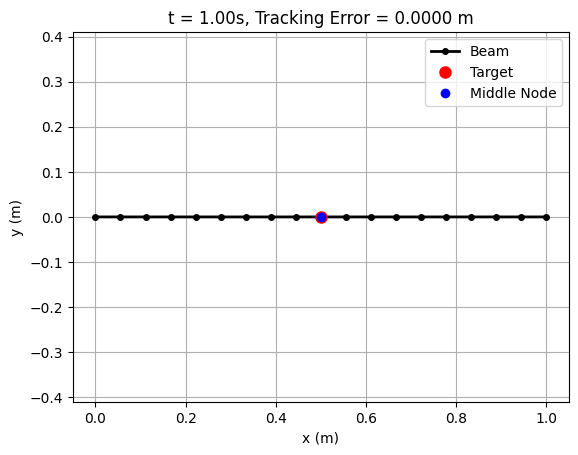

Step 1/1000, t = 1.00s, Err = 0.0000 m


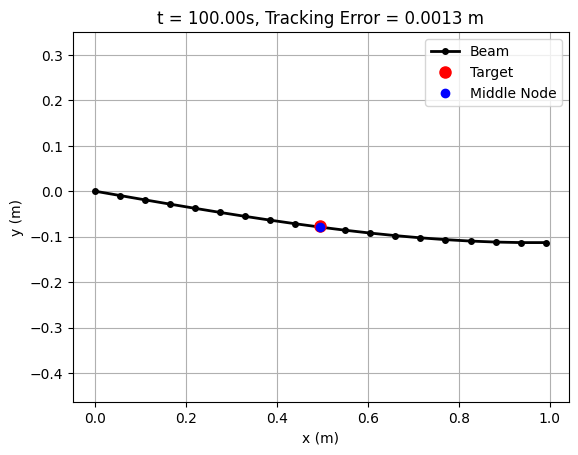

Step 100/1000, t = 100.00s, Err = 0.0013 m


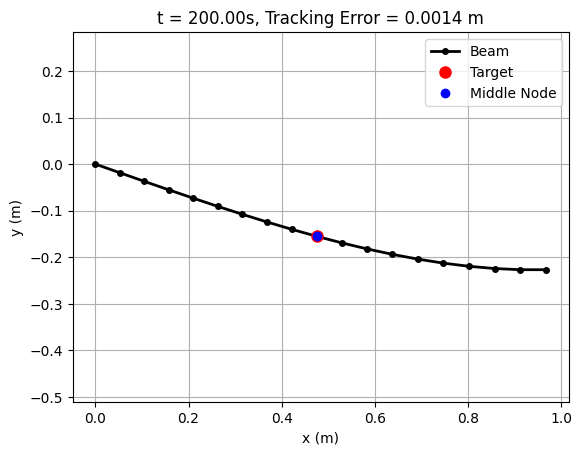

Step 200/1000, t = 200.00s, Err = 0.0014 m


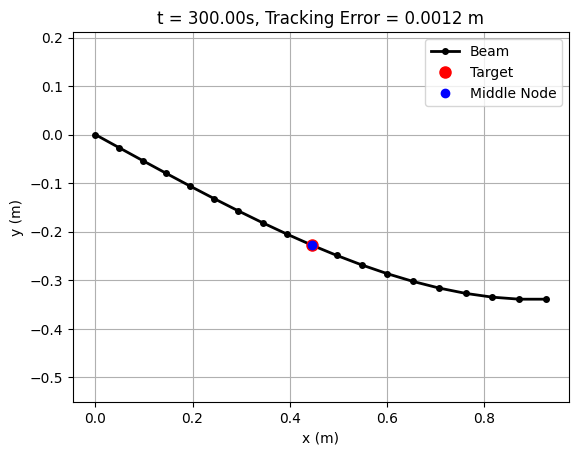

Step 300/1000, t = 300.00s, Err = 0.0012 m


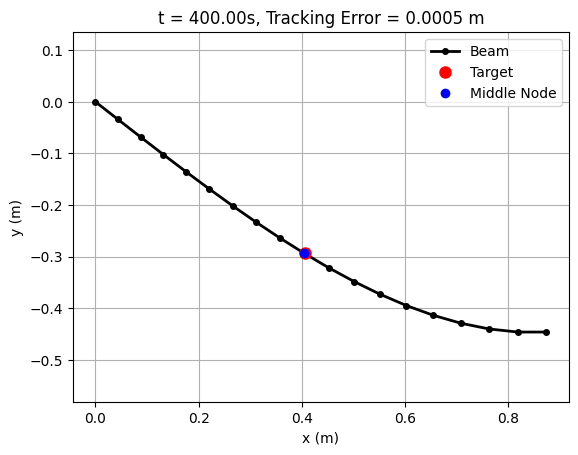

Step 400/1000, t = 400.00s, Err = 0.0005 m


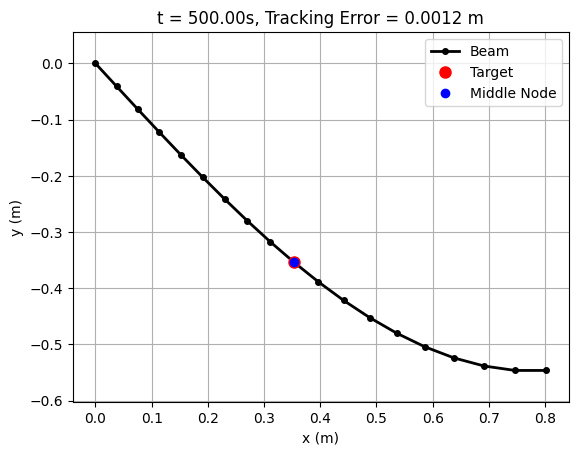

Step 500/1000, t = 500.00s, Err = 0.0012 m


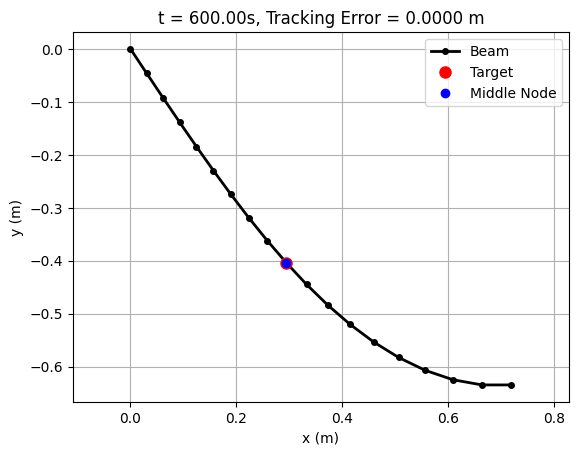

Step 600/1000, t = 600.00s, Err = 0.0000 m


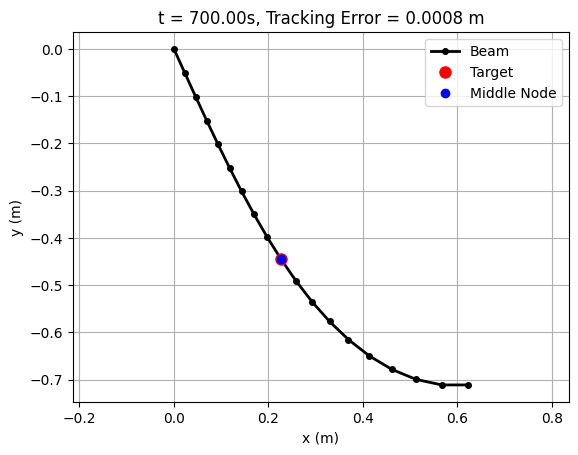

Step 700/1000, t = 700.00s, Err = 0.0008 m


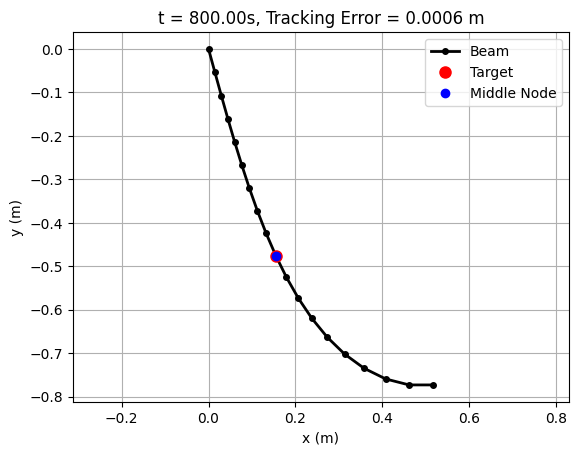

Step 800/1000, t = 800.00s, Err = 0.0006 m


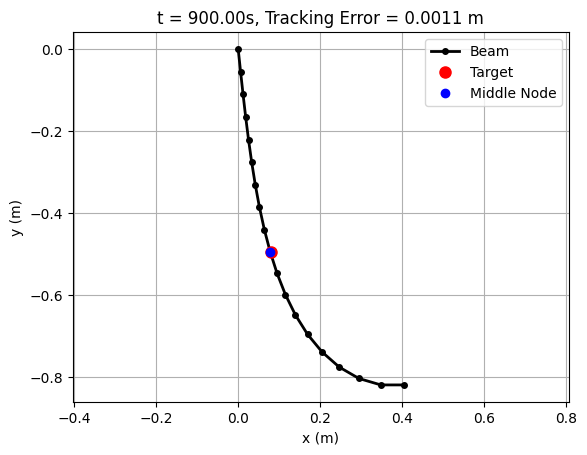

Step 900/1000, t = 900.00s, Err = 0.0011 m


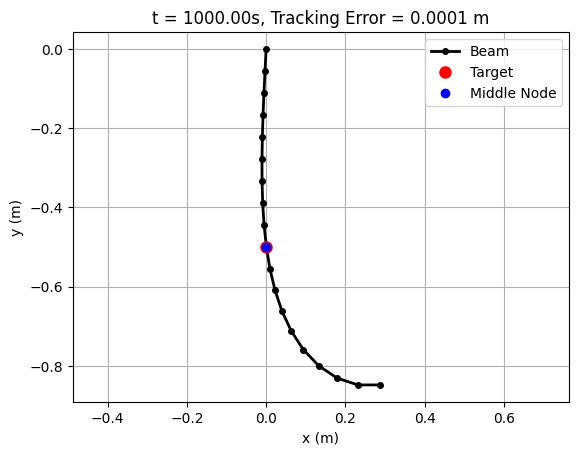

Step 1000/1000, t = 1000.00s, Err = 0.0001 m
Simulation completed!


In [586]:
# ============================================
# MAIN SIMULATION LOOP (PID END CONTROL)
# ============================================

Nsteps = round(totalTime / dt)
ctime = 0.0

# Storage arrays
all_pos = np.zeros(Nsteps)
all_vel = np.zeros(Nsteps)
x_star_history = np.zeros(Nsteps)
y_star_history = np.zeros(Nsteps)
snapshots = []
snapshot_times = [0, 200, 400, 600, 800, 1000]  # include 0 and 1000 for final plots

# PID gains (tuned for stability and low steady-state error)
Kp = 1.5
Ki = 1.5
Kd = 0.5

# Initialize control & tracking states
x_c = RodLength     # end-effector starts at beam tip
y_c = 0.0
thetac = 0.0
x_mid_prev = q0[2*(midNode-1)]
y_mid_prev = q0[2*(midNode-1)+1]
integral_error = [0.0, 0.0]

print("Starting simulation with PID end control...")

for timeStep in range(1, Nsteps + 1):

    # Desired middle-node trajectory (0 → 1000 s)
    x_star = RodLength/2 * np.cos(np.pi/2 * ctime/1000)
    y_star = -RodLength/2 * np.sin(np.pi/2 * ctime/1000)
    x_star_history[timeStep-1] = x_star
    y_star_history[timeStep-1] = y_star

    # Current middle node position
    x_mid = q0[2*(midNode-1)]
    y_mid = q0[2*(midNode-1)+1]

    # --- Compute PID-based end-effector control ---
    x_c, y_c, thetac, integral_error = compute_control_inputs(
        x_star, y_star, x_mid, y_mid,
        x_mid_prev, y_mid_prev,
        x_c, y_c, integral_error, dt,
        Kp, Ki, Kd
    )

    # --- Rate limiting to stabilize objfun() ---
    max_step = 0.002  # max end motion (m) per step
    dx = x_c - q0[2*(nv-1)]
    dy = y_c - q0[2*(nv-1)+1]
    move_mag = np.sqrt(dx**2 + dy**2)
    if move_mag > max_step:
        scale = max_step / move_mag
        x_c = q0[2*(nv-1)] + dx * scale
        y_c = q0[2*(nv-1)+1] + dy * scale

    # Save previous middle node position for next derivative step
    x_mid_prev, y_mid_prev = x_mid, y_mid

    # Apply Dirichlet constraints BEFORE objfun()
    q0[2*(nv-1)]   = x_c
    q0[2*(nv-1)+1] = y_c
    q0[2*(nv-2)]   = x_c - deltaL * np.cos(thetac)
    q0[2*(nv-2)+1] = y_c - deltaL * np.sin(thetac)

    # Fix both ends (avoid singular matrix)
    fixed_right = np.array([2*(nv-1), 2*(nv-1)+1,
                            2*(nv-2), 2*(nv-2)+1])
    current_fixed = np.concatenate((fixed_left, fixed_right))
    current_free = np.setdiff1d(all_DOFs, current_fixed)

    # --- Solve beam dynamics ---
    q_new, error = objfun(q0, u0, dt, tol, maximum_iter,
                          m, mMat, EI, EA, W, C,
                          deltaL, current_free)

    if error < 0:
        print(f"Convergence failed at step {timeStep}, t={ctime:.2f}s")
        print("Suggestion: lower PID gains or dt further.")
        break

    # Update time and velocities
    u_new = (q_new - q0) / dt
    ctime += dt
    q0 = q_new.copy()
    u0 = u_new.copy()

    # Update middle node (for plotting and error)
    x_mid = q_new[2*(midNode-1)]
    y_mid = q_new[2*(midNode-1)+1]
    all_pos[timeStep-1] = y_mid

    # Store snapshots
    if any(abs(ctime - t) < dt/2 for t in snapshot_times):
        snapshots.append((ctime, q_new.copy()))

    # --- Plot progress (every few steps) ---
    if timeStep % plotStep == 0 or timeStep == 1 or timeStep == Nsteps:
        x_arr = q_new[::2]
        y_arr = q_new[1::2]
        err = np.sqrt((x_star - x_mid)**2 + (y_star - y_mid)**2)

        plt.figure(1)
        plt.clf()
        plt.plot(x_arr, y_arr, 'ko-', linewidth=2, markersize=4, label='Beam')
        plt.plot(x_star, y_star, 'ro', markersize=8, label='Target')
        plt.plot(x_mid, y_mid, 'bo', markersize=6, label='Middle Node')
        plt.title(f't = {ctime:.2f}s, Tracking Error = {err:.4f} m')
        plt.xlabel('x (m)')
        plt.ylabel('y (m)')
        plt.axis('equal')
        plt.grid(True)
        plt.legend()
        plt.show()

        print(f"Step {timeStep}/{Nsteps}, t = {ctime:.2f}s, Err = {err:.4f} m")

print("Simulation completed!")





**more plots**


Generating comprehensive plots...


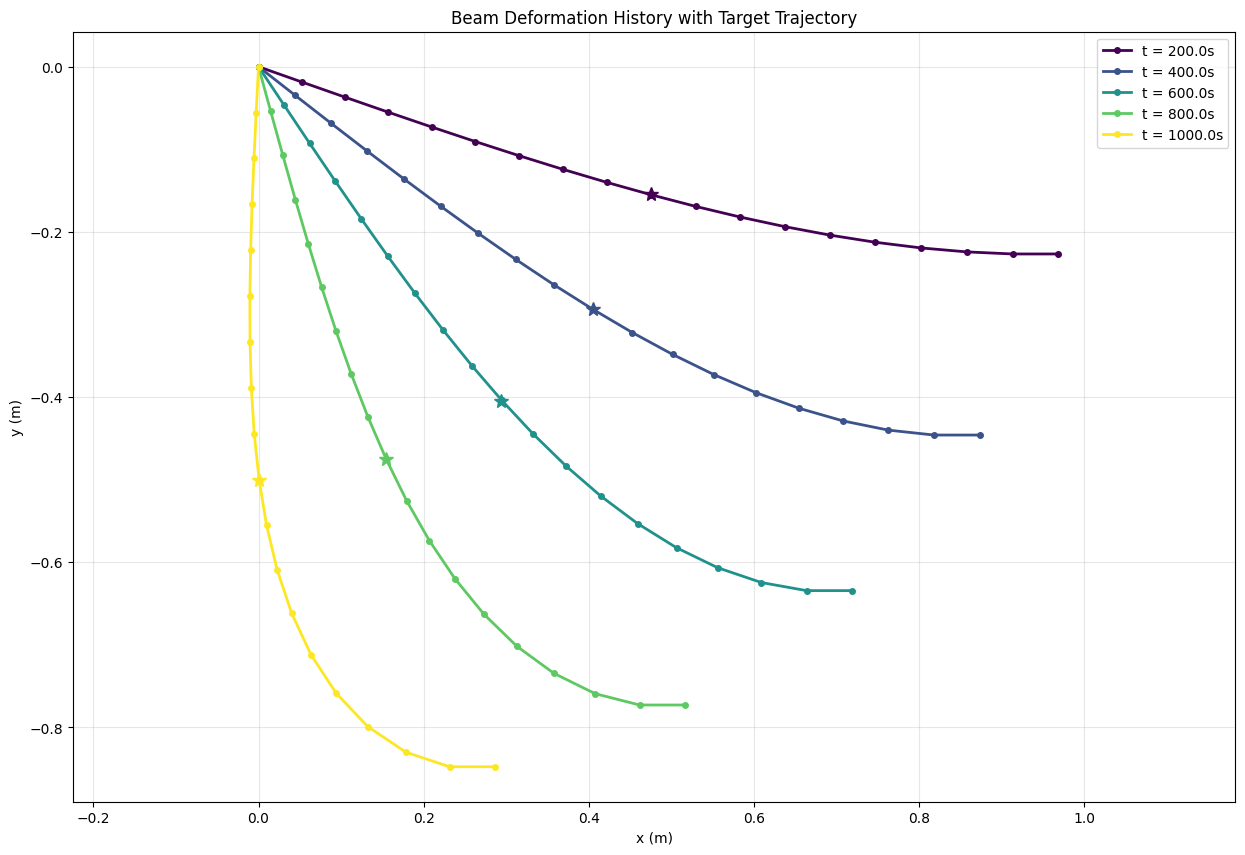

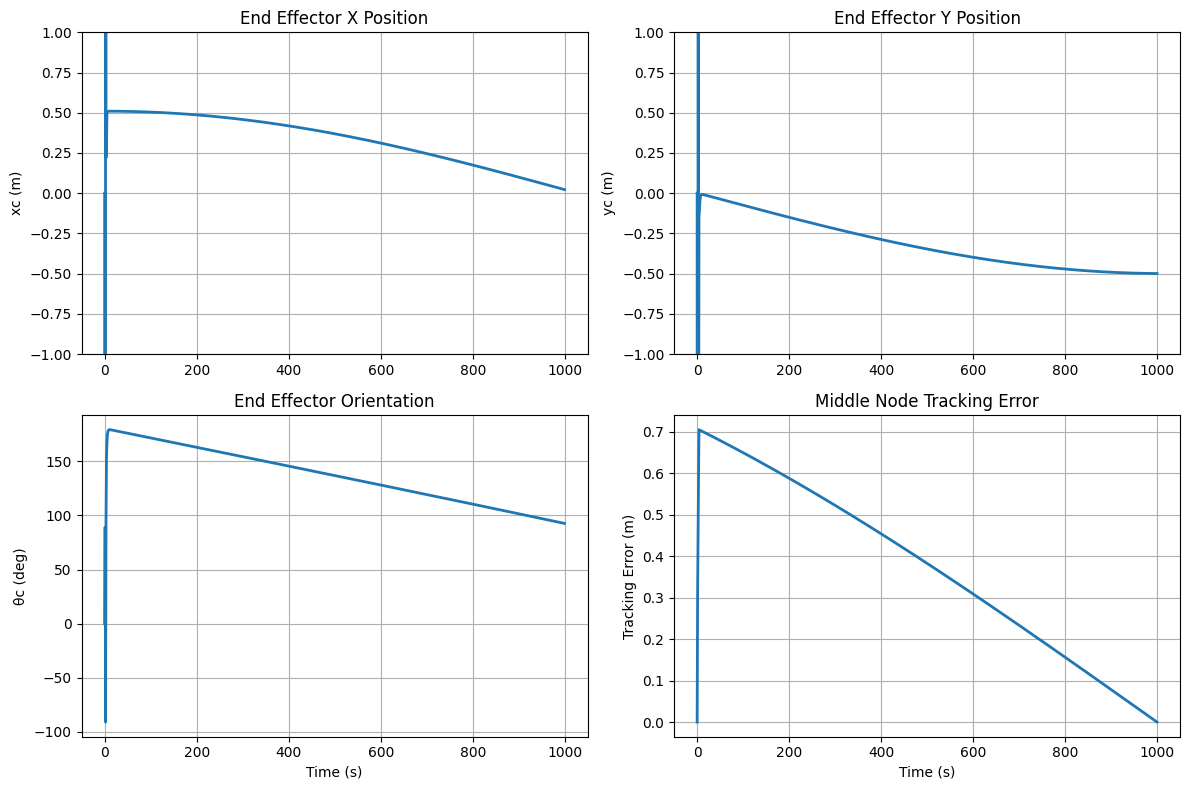

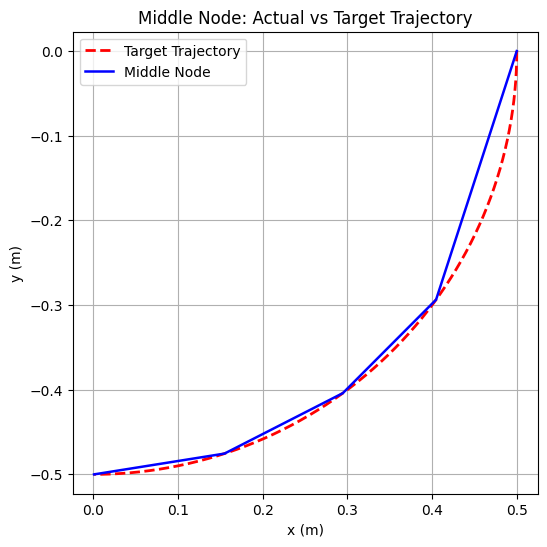

All plots generated successfully!


In [588]:
# ================================
# AFTER-SIMULATION: REQUIRED PLOTS
# ================================

print("\nGenerating comprehensive plots...")

# --- Ensure middle-node history arrays exist (fill from snapshots if needed) ---
if 'mid_x_history' not in locals() or len(mid_x_history) == 0:
    mid_x_history = np.zeros(Nsteps)
    mid_y_history = np.zeros(Nsteps)
    for i in range(Nsteps):
        mid_x_history[i] = q0[2*(midNode-1)] if i >= len(snapshots) else snapshots[min(i, len(snapshots)-1)][1][2*(midNode-1)]
        mid_y_history[i] = q0[2*(midNode-1)+1] if i >= len(snapshots) else snapshots[min(i, len(snapshots)-1)][1][2*(midNode-1)+1]

# --- Set physically correct starting point for middle node ---
mid_x_history[0] = RodLength / 2.0
mid_y_history[0] = 0.0


# 2) Deformation history (≥ 5 snapshots over time)
if snapshots:
    plot_rod_deformation_history(snapshots, midNode-1)

# 3) Control inputs over time (xc, yc, θc)
t_axis = np.arange(Nsteps) * dt
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Zoomed control-input plots: ±2 m range ---
axes[0, 0].plot(t_axis, xc_history/100, linewidth=2)
axes[0, 0].set_ylabel('xc (m)')
axes[0, 0].set_title('End Effector X Position')
axes[0, 0].set_ylim([-1, 1])
axes[0, 0].grid(True)

axes[0, 1].plot(t_axis, yc_history/100, linewidth=2)
axes[0, 1].set_ylabel('yc (m)')
axes[0, 1].set_title('End Effector Y Position')
axes[0, 1].set_ylim([-1, 1])
axes[0, 1].grid(True)

axes[1, 0].plot(t_axis, np.degrees(theta_c_history), linewidth=2)
axes[1, 0].set_ylabel('θc (deg)')
axes[1, 0].set_xlabel('Time (s)')
axes[1, 0].set_title('End Effector Orientation')
axes[1, 0].grid(True)

# 4) Tracking error over time
tracking_error = np.sqrt((x_star_history - mid_x_history)**2 +
                         (y_star_history - mid_y_history)**2)
axes[1, 1].plot(t_axis, tracking_error, linewidth=2)
axes[1, 1].set_ylabel('Tracking Error (m)')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_title('Middle Node Tracking Error')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

# 5) Middle node trajectory vs target trajectory (full domain, not zoomed)
plt.figure(figsize=(6, 6))
plt.plot(x_star_history, y_star_history, 'r--', linewidth=2, label='Target Trajectory')
plt.plot(mid_x_history, mid_y_history, 'b-', linewidth=1.8, label='Middle Node')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Middle Node: Actual vs Target Trajectory')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

print("All plots generated successfully!")